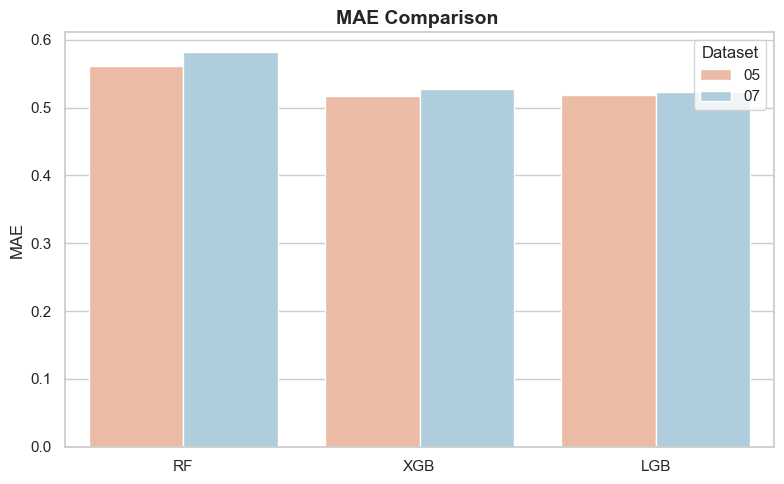

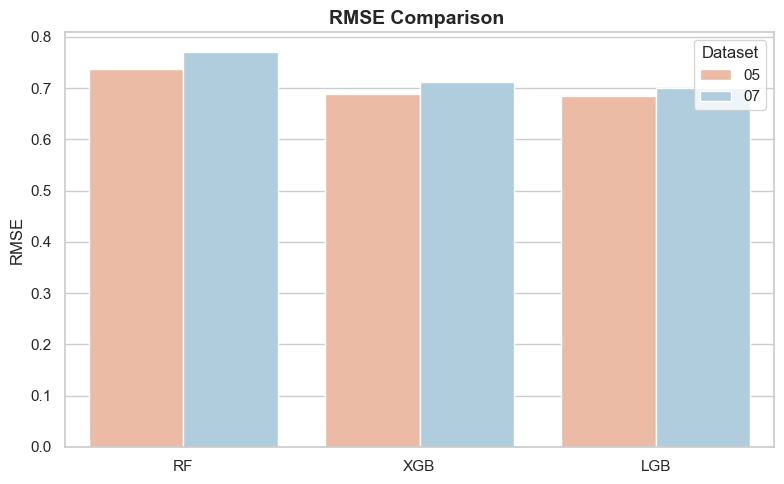

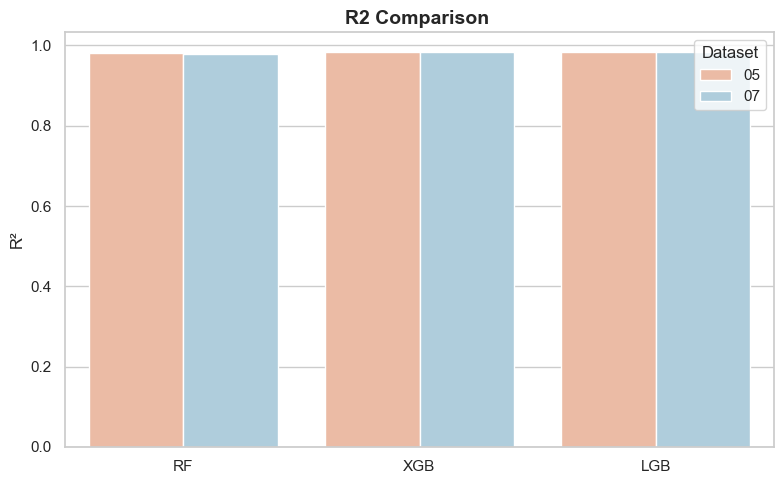

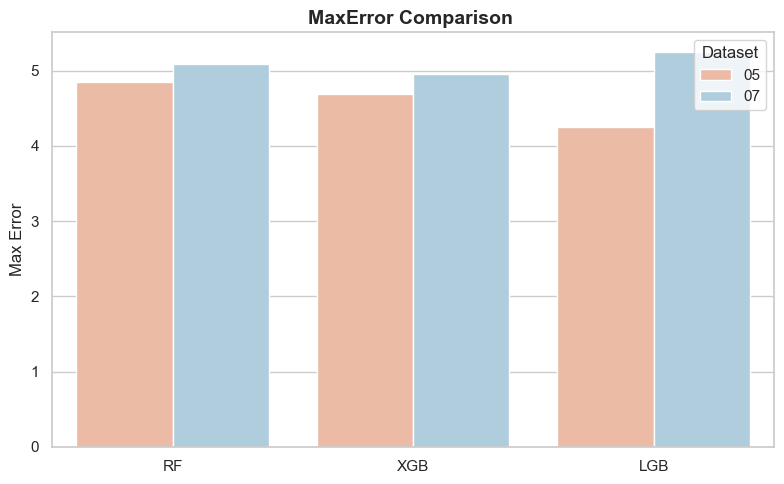

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# raw evaluation result
data = {
    "Model": ["RF","XGB","LGB"] * 2,
    "Dataset": ["05"]*3 + ["07"]*3,

    "MAE": [
        0.5612539201530198, 0.5174809982446376, 0.5181057602123259,
        0.5819213041010316, 0.5275908424812704, 0.5227956567143205
    ],

    "RMSE": [
        0.7372941628502372, 0.6881523534638848, 0.6838496686115392,
        0.770180980798084, 0.7116840980225715, 0.700036511664648
    ],

    "R2": [
        0.9809608116531741, 0.9834142147488408, 0.9836209721801552,
        0.9798755052388806, 0.9828164088716351, 0.9833742674304533
    ],

    "MaxError": [
        4.8436112280952415, 4.689192579345729, 4.25088063704497,
        5.082511033333386, 4.96046570129397, 5.246589522913869
    ]
}

df = pd.DataFrame(data)


sns.set(style="whitegrid")


def plot_metric(metric_name, ylabel):
    plt.figure(figsize=(8,5))

    sns.barplot(
        data=df,
        x="Model",
        y=metric_name,
        hue="Dataset",
        palette="RdBu",
        errorbar="sd",
        capsize=0.1
    )

    plt.title(f"{metric_name} Comparison ", fontsize=14, weight='bold')
    plt.ylabel(ylabel)
    plt.xlabel("")

    plt.legend(title="Dataset")
    plt.tight_layout()
    plt.show()

plot_metric("MAE", "MAE")
plot_metric("RMSE", "RMSE")
plot_metric("R2", "R²")
plot_metric("MaxError", "Max Error")

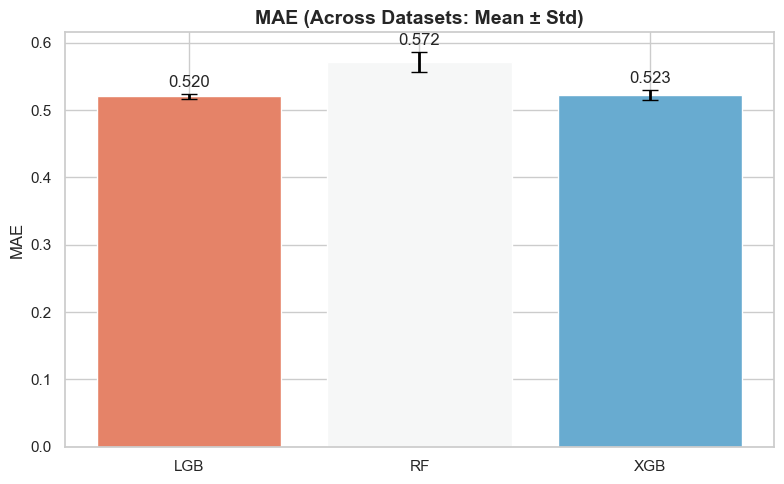

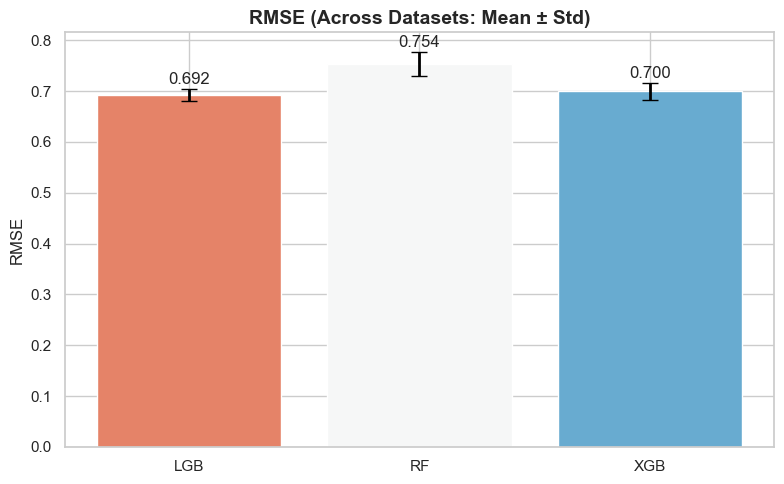

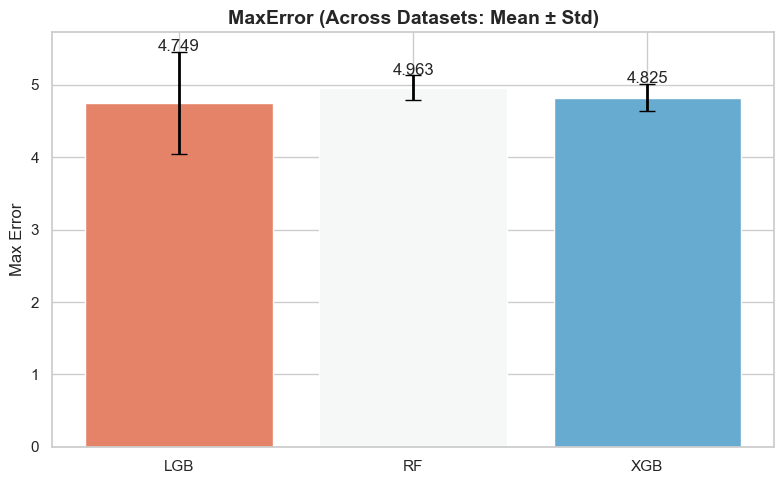

In [11]:
# mean + std
metrics = ["MAE", "RMSE", "MaxError"]

summary = df.groupby("Model")[metrics].agg(["mean", "std"]).reset_index()

summary.columns = ["Model"] + [f"{m}_{s}" for m in metrics for s in ["mean", "std"]]

def plot_metric(metric, ylabel):
    plt.figure(figsize=(8,5))

    models = summary["Model"]
    means = summary[f"{metric}_mean"]
    stds  = summary[f"{metric}_std"]

    colors = sns.color_palette("RdBu", len(models))

    plt.bar(models, means, color=colors)


    plt.errorbar(
        x=models,
        y=means,
        yerr=stds,
        fmt='none',
        ecolor='black',
        capsize=6,
        linewidth=2
    )

    for i, v in enumerate(means):
        plt.text(i, v + stds[i] + 0.01, f"{v:.3f}", ha='center')

    plt.title(f"{metric} (Across Datasets: Mean ± Std)", fontsize=14, weight='bold')
    plt.ylabel(ylabel)
    plt.xlabel("")

    plt.tight_layout()
    plt.show()


plot_metric("MAE", "MAE")
plot_metric("RMSE", "RMSE")
plot_metric("MaxError", "Max Error")

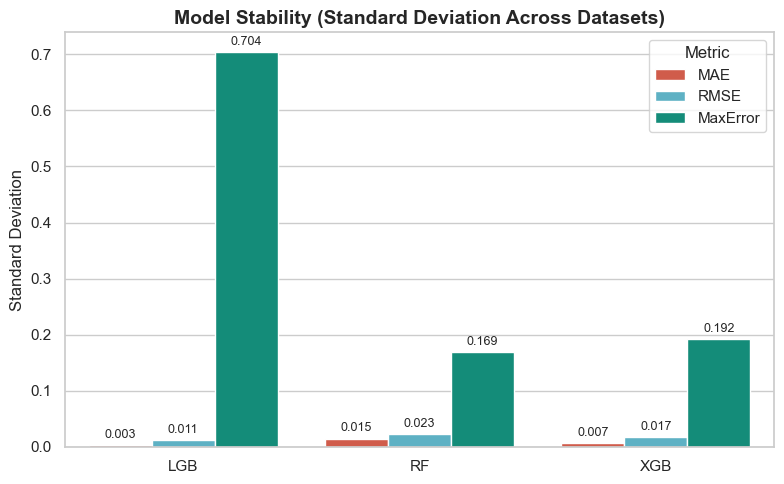

In [16]:


std_df = df.groupby("Model")[metrics].std().reset_index()


std_long = std_df.melt(
    id_vars="Model",
    value_vars=metrics,
    var_name="Metric",
    value_name="STD"
)


palette = {
    "MAE": "#E64B35",
    "RMSE": "#4DBBD5",
    "MaxError": "#00A087"
}

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=std_long,
    x="Model",
    y="STD",
    hue="Metric",
    palette=palette
)


for p in ax.patches:
    height = p.get_height()


    if height > 0:
        ax.annotate(
            f"{height:.3f}",
            (p.get_x() + p.get_width() / 2, height),
            ha='center',
            va='bottom',
            fontsize=9,
            xytext=(0, 3),
            textcoords='offset points'
        )

plt.title("Model Stability (Standard Deviation Across Datasets)", fontsize=14, weight='bold')
plt.ylabel("Standard Deviation")
plt.xlabel("")

plt.legend(title="Metric")

plt.tight_layout()
plt.show()